**QUESTION 1A**

/usr/local/lib/python3.13/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: Monthly!$A:$F.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


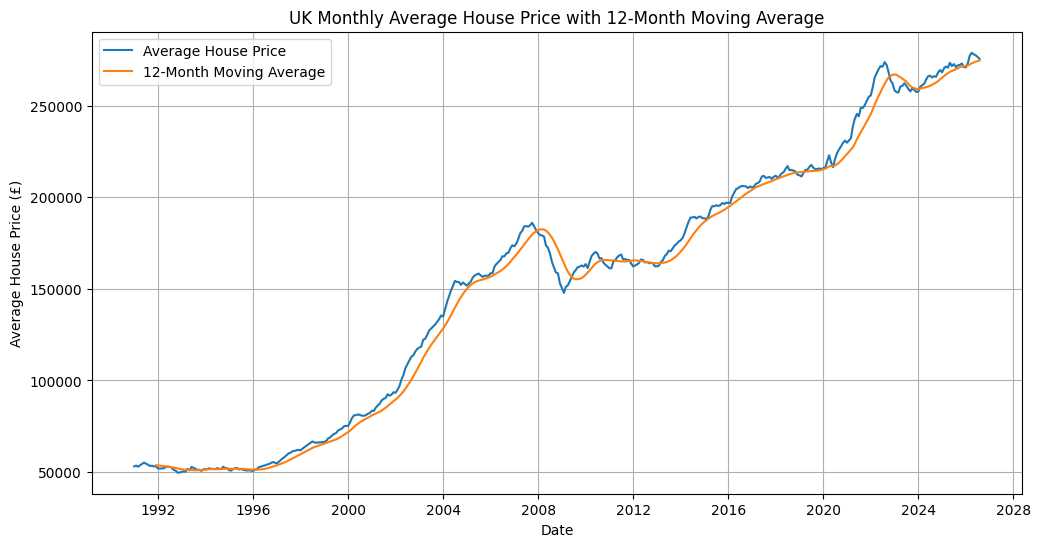

Start date: January 1991
End date: August 2026


In [ ]:
#load the monthly house price data
house_price_df = pd.read_excel('Monthly.xlsx', sheet_name='Monthly', usecols='A:B')
#rename the date column
house_price_df = house_price_df.rename(columns={'Unnamed: 0': 'Date'})

#calculate the 12-month moving average
house_price_df['MA12'] = house_price_df['Average House Price'].rolling(window=12).mean()

#plot the house price and 12-month moving average
plt.figure(figsize=(12, 6))
plt.plot(house_price_df['Date'], house_price_df['Average House Price'], label='Average House Price')
plt.plot(house_price_df['Date'], house_price_df['MA12'], label='12-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Average House Price (£)')
plt.title('UK Monthly Average House Price with 12-Month Moving Average')
plt.legend()
plt.grid()
plt.show()

print(f"Start date: {house_price_df['Date'].min().strftime('%B %Y')}")
print(f"End date: {house_price_df['Date'].max().strftime('%B %Y')}")

**QUESTION 1B**

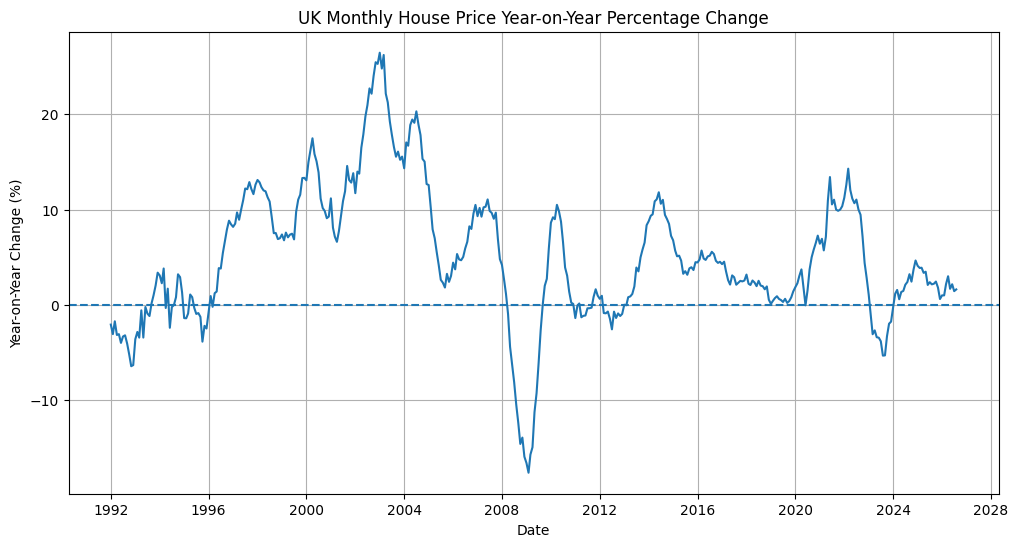

Sharpest growth: January 2003 (26.47%)
Sharpest decline: February 2009 (-17.63%)


In [ ]:
#calculate the year-on-year percentage change
house_price_df['YoY % Change'] = (house_price_df['Average House Price'] / house_price_df['Average House Price'].shift(12) - 1) * 100

#plot the year-on-year percentage change
plt.figure(figsize=(12, 6))
plt.plot(house_price_df['Date'], house_price_df['YoY % Change'])
plt.axhline(0, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Year-on-Year Change (%)')
plt.title('UK Monthly House Price Year-on-Year Percentage Change')
plt.grid()
plt.show()

#identify the sharpest growth and decline
sharpest_growth = house_price_df.loc[house_price_df['YoY % Change'].idxmax()]
sharpest_decline = house_price_df.loc[house_price_df['YoY % Change'].idxmin()]

print(f"Sharpest growth: {sharpest_growth['Date'].strftime('%B %Y')} ({sharpest_growth['YoY % Change']:.2f}%)")
print(f"Sharpest decline: {sharpest_decline['Date'].strftime('%B %Y')} ({sharpest_decline['YoY % Change']:.2f}%)")

**QUESTION 1C**

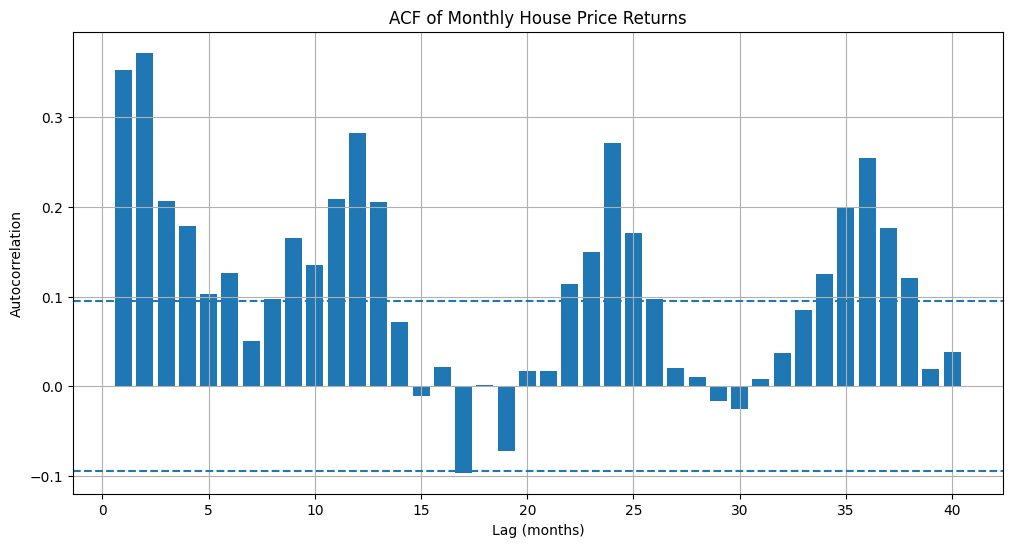

Number of monthly returns: 427
Approximate 5% significance threshold: ±0.0949


In [ ]:
from statsmodels.tsa.stattools import acf

#calculate the monthly returns
house_price_df['Monthly Return'] = house_price_df['Average House Price'] / house_price_df['Average House Price'].shift(1) - 1

#remove the missing first return
monthly_returns = house_price_df['Monthly Return'].dropna()

#calculate the ACF for lags 1 through 40
acf_values = acf(monthly_returns, nlags=40, fft=False)

#calculate the approximate 5% significance threshold
n_returns = len(monthly_returns)
acf_threshold = 1.96 / np.sqrt(n_returns)

#plot the ACF
lags = np.arange(1, 41)

plt.figure(figsize=(12, 6))
plt.bar(lags, acf_values[1:41])
plt.axhline(acf_threshold, linestyle='--')
plt.axhline(-acf_threshold, linestyle='--')
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation')
plt.title('ACF of Monthly House Price Returns')
plt.grid()
plt.show()

print(f"Number of monthly returns: {n_returns}")
print(f"Approximate 5% significance threshold: ±{acf_threshold:.4f}")

**QUESTION 1D**


In [ ]:
#full period
full_start_price = house_price_df.loc[house_price_df['Date'] == '1991-01-01', 'Average House Price'].iloc[0]
full_end_price = house_price_df.loc[house_price_df['Date'] == '2026-08-01', 'Average House Price'].iloc[0]
full_start_date = pd.Timestamp('1991-01-01')
full_end_date = pd.Timestamp('2026-08-01')
full_years = (full_end_date.year - full_start_date.year) + (full_end_date.month - full_start_date.month) / 12
full_cagr = (full_end_price / full_start_price) ** (1 / full_years) - 1

#pre-2008 period
pre_start_price = house_price_df.loc[house_price_df['Date'] == '1991-01-01', 'Average House Price'].iloc[0]
pre_end_price = house_price_df.loc[house_price_df['Date'] == '2007-12-01', 'Average House Price'].iloc[0]
pre_start_date = pd.Timestamp('1991-01-01')
pre_end_date = pd.Timestamp('2007-12-01')
pre_years = (pre_end_date.year - pre_start_date.year) + (pre_end_date.month - pre_start_date.month) / 12
pre_cagr = (pre_end_price / pre_start_price) ** (1 / pre_years) - 1

#post-2008 period
post_start_price = house_price_df.loc[house_price_df['Date'] == '2008-01-01', 'Average House Price'].iloc[0]
post_end_price = house_price_df.loc[house_price_df['Date'] == '2026-08-01', 'Average House Price'].iloc[0]
post_start_date = pd.Timestamp('2008-01-01')
post_end_date = pd.Timestamp('2026-08-01')
post_years = (post_end_date.year - post_start_date.year) + (post_end_date.month - post_start_date.month) / 12
post_cagr = (post_end_price / post_start_price) ** (1 / post_years) - 1

print(f"Full-period CAGR: {full_cagr * 100:.2f}%")
print(f"Pre-2008 CAGR: {pre_cagr * 100:.2f}%")
print(f"Post-2008 CAGR: {post_cagr * 100:.2f}%")

Full-period CAGR: 4.74%
Pre-2008 CAGR: 7.56%
Post-2008 CAGR: 2.30%


**QUESTION 2A**


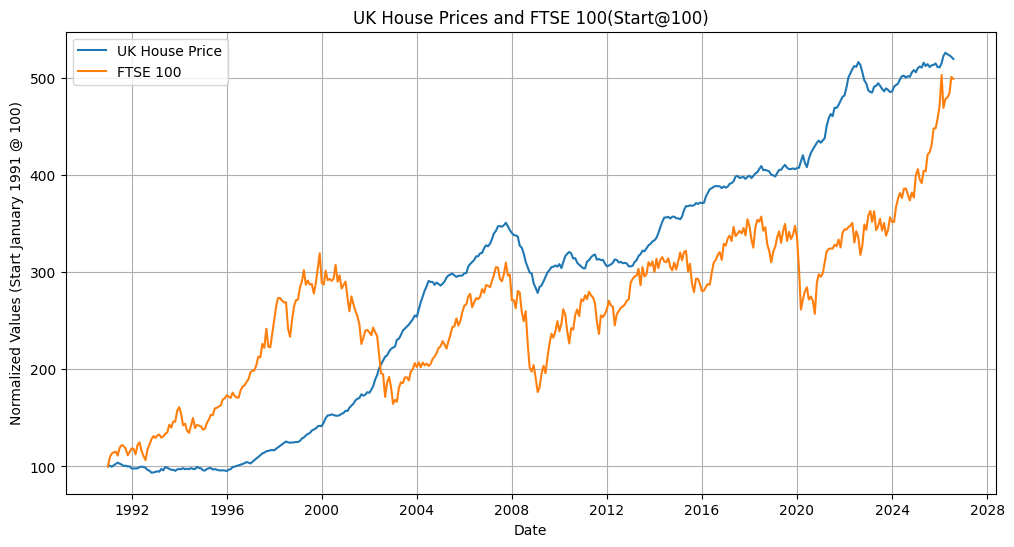

In [ ]:
#load the FTSE 100 data
ftse_df = pd.read_csv('FTSE100.csv')
#convert the date column to datetime
ftse_df['Date'] = pd.to_datetime(ftse_df['Date'])

#keep the same period as the house price data
ftse_df = ftse_df[(ftse_df['Date'] >= '1991-01-01') & (ftse_df['Date'] <= '2026-08-31')].copy()

#normalize the house price and FTSE 100 series to start at 100
house_price_df['Normalized House Price'] = house_price_df['Average House Price'] / house_price_df['Average House Price'].iloc[0] * 100
ftse_df['Normalized FTSE'] = ftse_df['Adj Close'] / ftse_df['Adj Close'].iloc[0] * 100

#plot both normalized series
plt.figure(figsize=(12, 6))
plt.plot(house_price_df['Date'], house_price_df['Normalized House Price'], label='UK House Price')
plt.plot(ftse_df['Date'], ftse_df['Normalized FTSE'], label='FTSE 100')
plt.xlabel('Date')
plt.ylabel('Normalized Values (Start January 1991 @ 100)')
plt.title('UK House Prices and FTSE 100(Start@100)')
plt.legend()
plt.grid()
plt.show()

**QUESTION 2B**

In [ ]:
#calculate the number of years in the period
start_date = ftse_df['Date'].iloc[0]
end_date = ftse_df['Date'].iloc[-1]
years = (end_date - start_date).days / 365.25

#calculate the geometric annualized return
ftse_cagr = (ftse_df['Adj Close'].iloc[-1] / ftse_df['Adj Close'].iloc[0]) ** (1 / years) - 1

print(f"The annualized return(geometric) is: {ftse_cagr * 100:.2f}%")

The annualized return(geometric) is: 4.62%


**QUESTION 2C**

In [ ]:
#calculate monthly returns for house prices
house_price_df['Monthly Return'] = house_price_df['Average House Price'] / house_price_df['Average House Price'].shift(1) - 1

#calculate monthly returns for the FTSE 100
ftse_df['Monthly Return'] = ftse_df['Adj Close'] / ftse_df['Adj Close'].shift(1) - 1

#remove the missing first return which is now NaN
house_returns = house_price_df['Monthly Return'].dropna()
ftse_returns = ftse_df['Monthly Return'].dropna()


#calculate the standard deviation of monthly returns
house_monthly_std = np.std(house_returns, ddof=1)
ftse_monthly_std = np.std(ftse_returns, ddof=1)

#calculate the annualized volatility
house_annualized_volatility = house_monthly_std * np.sqrt(12)
ftse_annualized_volatility = ftse_monthly_std * np.sqrt(12)

#calculate house price CAGR for comparison
house_cagr = (house_price_df['Average House Price'].iloc[-1] / house_price_df['Average House Price'].iloc[0]) ** (1 / years) - 1

print(f"The standard deviation of monthly returns for House price is {house_monthly_std * 100:.2f}%")
print(f"The standard deviation of monthly returns for FTSE 100 is {ftse_monthly_std * 100:.2f}%")
print(f"House price annualized volatility is {house_annualized_volatility * 100:.2f}%")
print(f"FTSE 100 annualized volatility is {ftse_annualized_volatility * 100:.2f}%")

The standard deviation of monthly returns for House price is 1.06%
The standard deviation of monthly returns for FTSE 100 is 3.86%
House price annualized volatility is 3.67%
FTSE 100 annualized volatility is 13.38%
